# Loading dependencies

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gc
from torch.utils.data import Dataset, DataLoader

# Loading data

In [2]:
base = '/kaggle/input/datasets/siladavid/random-patch-iso-z/'
use_inputs = ['Bx', 'By', 'Bz']
Z_LEVELS   = [10, 16, 22]
N_Z        = 35

def load_npz(path):
    data = np.load(path, allow_pickle=True)
    return {k: v for k, v in data.items()}

train_data = load_npz(base + 'train.npz')
val_data   = load_npz(base + 'val.npz')
test_data  = load_npz(base + 'test.npz')

# --- Train ---
T_train_p   = train_data['T_train']           # (N, 32, 32, 35)
p_train_p   = train_data['p_train']
vx_train_p  = train_data['vx_train']
vy_train_p  = train_data['vy_train']
vz_train_p  = train_data['vz_train']
Bx_train_p  = train_data['Bx_train']
By_train_p  = train_data['By_train']
Bz_train_p  = train_data['Bz_train']
tau_train_p = train_data['tau_train'][..., Z_LEVELS]  # (N, 32, 32, 3)
train_img_id   = train_data['train_img_id']
train_patch_id = train_data['train_patch_id']
train_pos_i    = train_data['train_pos_i']
train_pos_j    = train_data['train_pos_j']
del train_data; gc.collect()

# --- Val ---
T_val_p   = val_data['T_val']
p_val_p   = val_data['p_val']
vx_val_p  = val_data['vx_val']
vy_val_p  = val_data['vy_val']
vz_val_p  = val_data['vz_val']
Bx_val_p  = val_data['Bx_val']
By_val_p  = val_data['By_val']
Bz_val_p  = val_data['Bz_val']
tau_val_p = val_data['tau_val'][..., Z_LEVELS]
val_img_id   = val_data['val_img_id']
val_patch_id = val_data['val_patch_id']
val_pos_i    = val_data['val_pos_i']
val_pos_j    = val_data['val_pos_j']
del val_data; gc.collect()

# --- Test (ceo cube 1536x1536x35) ---
T_test_p   = test_data['T_test']
p_test_p   = test_data['p_test']
vx_test_p  = test_data['vx_test']
vy_test_p  = test_data['vy_test']
vz_test_p  = test_data['vz_test']
Bx_test_p  = test_data['Bx_test']
By_test_p  = test_data['By_test']
Bz_test_p  = test_data['Bz_test']
tau_test_p = test_data['tau_test'][..., Z_LEVELS]   # (1536, 1536, 3)
test_img_id = test_data['test_img_id']
z_axis      = test_data['z_axis']
del test_data; gc.collect()

print(f"Train: {T_train_p.shape} | tau: {tau_train_p.shape}")
print(f"Val:   {T_val_p.shape}   | tau: {tau_val_p.shape}")
print(f"Test:  {T_test_p.shape}  | tau: {tau_test_p.shape}")

Train: (8640, 32, 32, 35) | tau: (8640, 32, 32, 3)
Val:   (2160, 32, 32, 35)   | tau: (2160, 32, 32, 3)
Test:  (1536, 1536, 35)  | tau: (1536, 1536, 3)


# Normalizing inputs

In [3]:
norm_stats = {}
B_VARS = {'Bx', 'By', 'Bz'}  

def normalize_fit(patches, name):
    """T/p/v/tau: z-score for every z. B: arcsinh(B/std)"""
    
    if name in B_VARS:
        beta = patches.std(axis=(0,1,2)) + 1e-8     # (Nz,)
        patches = np.arcsinh(patches / beta)
        norm_stats[name] = {'beta': beta}
        
    mean = patches.mean(axis=(0,1,2))
    std  = patches.std(axis=(0,1,2))
    norm_stats.setdefault(name, {}).update({'mean': mean, 'std': std})
    return (patches - mean) / (std + 1e-8)

def normalize_apply(patches, name):
    if name in B_VARS:
        patches = np.arcsinh(patches / norm_stats[name]['beta'])
    mean = norm_stats[name]['mean']
    std  = norm_stats[name]['std']
    return (patches - mean) / (std + 1e-8)

def normalize_apply_2d(cube, name):
    """For test cube (1536,1536,Nz) — broadcast on z."""
    if name in B_VARS:
        beta = norm_stats[name]['beta'].reshape(1, 1, -1)
        cube = np.arcsinh(cube / beta)
    mean = norm_stats[name]['mean'].reshape(1, 1, -1)
    std  = norm_stats[name]['std'].reshape(1, 1, -1)
    return (cube - mean) / (std + 1e-8)

In [4]:
norm_stats = {}

def normalize_fit(patches, name):
    """Fit mean/std po z-nivou na train. patches: (N,H,W,Nz)"""
    mean = patches.mean(axis=(0,1,2))   # (Nz,)
    std  = patches.std(axis=(0,1,2))
    norm_stats[name] = {'mean': mean, 'std': std}
    return (patches - mean) / (std + 1e-8)

def normalize_apply(patches, name):
    mean = norm_stats[name]['mean']
    std  = norm_stats[name]['std']
    return (patches - mean) / (std + 1e-8)

def normalize_apply_2d(cube, name):
    """Za test cube (1536,1536,Nz) — broadcast po z."""
    mean = norm_stats[name]['mean'].reshape(1, 1, -1)
    std  = norm_stats[name]['std'].reshape(1, 1, -1)
    return (cube - mean) / (std + 1e-8)

In [5]:
# Train (fit)
INPUTS_TRAIN = {'T': T_train_p, 'p': p_train_p,
                'vx': vx_train_p, 'vy': vy_train_p, 'vz': vz_train_p,
                'Bx': Bx_train_p, 'By': By_train_p, 'Bz': Bz_train_p}
INPUTS_TRAIN_NORM = {k: normalize_fit(v, k) for k, v in INPUTS_TRAIN.items()}

Y_train_norm = normalize_fit(tau_train_p, 'tau')

del INPUTS_TRAIN, T_train_p, p_train_p, vx_train_p, vy_train_p, vz_train_p, tau_train_p
del Bx_train_p, By_train_p, Bz_train_p
gc.collect()

# Val (apply)
INPUTS_VAL = {'T': T_val_p, 'p': p_val_p,
              'vx': vx_val_p, 'vy': vy_val_p, 'vz': vz_val_p,
              'Bx': Bx_val_p, 'By': By_val_p, 'Bz': Bz_val_p}
INPUTS_VAL_NORM = {k: normalize_apply(v, k) for k, v in INPUTS_VAL.items()}
Y_val_norm = normalize_apply(tau_val_p, 'tau')
del INPUTS_VAL, T_val_p, p_val_p, vx_val_p, vy_val_p, vz_val_p, tau_val_p
del Bx_val_p, By_val_p, Bz_val_p
gc.collect()

# Test (apply) — full cube
INPUTS_TEST = {'T': T_test_p, 'p': p_test_p,
               'vx': vx_test_p, 'vy': vy_test_p, 'vz': vz_test_p,
               'Bx': Bx_test_p, 'By': By_test_p, 'Bz': Bz_test_p}
INPUTS_TEST_NORM = {k: normalize_apply_2d(v, k) for k, v in INPUTS_TEST.items()}

# tau_test_p is not normalized
del INPUTS_TEST, T_test_p, p_test_p, vx_test_p, vy_test_p, vz_test_p
del Bx_test_p, By_test_p, Bz_test_p
gc.collect()

0

# Stacking input channels

In [6]:
# Train/Val: (N, 32, 32, 175): Dataset makes them in (175, 32, 32)
X_train = np.concatenate([INPUTS_TRAIN_NORM[k] for k in use_inputs], axis=-1)
X_val   = np.concatenate([INPUTS_VAL_NORM[k]   for k in use_inputs], axis=-1)
Y_train = Y_train_norm
Y_val   = Y_val_norm
del INPUTS_TRAIN_NORM, INPUTS_VAL_NORM, Y_train_norm, Y_val_norm
gc.collect()

# Test
X_test = np.concatenate([INPUTS_TEST_NORM[k] for k in use_inputs], axis=-1)
del INPUTS_TEST_NORM
gc.collect()

print(f"X_train: {X_train.shape} | Y_train: {Y_train.shape}")
print(f"X_val:   {X_val.shape}   | Y_val:   {Y_val.shape}")
print(f"X_test:  {X_test.shape}  | Y_test:  {tau_test_p.shape}")
print(f"in_channels={X_train.shape[-1]} | out_channels={Y_train.shape[-1]}")

X_train: (8640, 32, 32, 105) | Y_train: (8640, 32, 32, 3)
X_val:   (2160, 32, 32, 105)   | Y_val:   (2160, 32, 32, 3)
X_test:  (1536, 1536, 105)  | Y_test:  (1536, 1536, 3)
in_channels=105 | out_channels=3


In [7]:
class MuRAMDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X   # (N, H, W, C)
        self.Y = Y

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(np.ascontiguousarray(self.X[idx].transpose(2,0,1)))
        y = torch.from_numpy(np.ascontiguousarray(self.Y[idx].transpose(2,0,1)))
        return x, y

    @property
    def in_channels(self):  return self.X.shape[-1]
    @property
    def out_channels(self): return self.Y.shape[-1]

pin = torch.cuda.is_available()
batchsize = 32
train_ds = MuRAMDataset(X_train, Y_train)
val_ds   = MuRAMDataset(X_val,   Y_val)
train_loader = DataLoader(train_ds, batch_size=batchsize, shuffle=True,  num_workers=4, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=batchsize, shuffle=False, num_workers=4, pin_memory=pin)

x_b, y_b = next(iter(train_loader))
print(f"Batch X: {x_b.shape} | Batch Y: {y_b.shape}")

Batch X: torch.Size([32, 105, 32, 32]) | Batch Y: torch.Size([32, 3, 32, 32])


# Defining convolutional neural network - UNet

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2, 2)
        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)
        # Decoder
        self.up1  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64,  kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        # Output
        self.output = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        b  = self.bottleneck(self.pool(s2))
        x  = self.dec1(torch.cat([self.up1(b), s2], dim=1))
        x  = self.dec2(torch.cat([self.up2(x), s1], dim=1))
        return self.output(x)

In [9]:
# Init
#######

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels  = train_ds.in_channels, out_channels = train_ds.out_channels).to(device)

# Check
x_test = torch.randn(2, train_ds.in_channels, 32, 32).to(device)
y_test = model(x_test)
print(f"Input:  {x_test.shape}")
print(f"Output: {y_test.shape}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri: {total_params:,}")

Input:  torch.Size([2, 105, 32, 32])
Output: torch.Size([2, 3, 32, 32])
Parametri: 1,923,011


# Loss functions

In [10]:
# Training
################

# criterion = nn.MSELoss()
criterion = nn.HuberLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x_b, y_b in loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        pred = model(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            pred = model(x_b)
            total_loss += criterion(pred, y_b).item()
    return total_loss / len(loader)

# Training loop

In [11]:
# Training
###########

EPOCHS = 100
best_val_loss = float('inf')
Train_loss = []
Val_loss = []
patience = 50
no_improve = 0

In [12]:
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = val_epoch(model, val_loader, criterion, device)

    Train_loss.append(train_loss)
    Val_loss.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_unet.pth')
        saved = 'Saved'
    else:
        no_improve += 1
        saved = f'(no improve {no_improve}/{patience})'

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"Train: {train_loss:.6f} | "
          f"Val: {val_loss:.6f} | "
          f"LR: {current_lr:.2e} | {saved}")

    if no_improve >= patience:
        print(f"\nEarly stopping on epoch {epoch}.")
        break

print(f"\nBest val loss: {best_val_loss:.6f}")

Epoch   1/100 | Train: 0.310166 | Val: 0.311620 | LR: 5.00e-04 | Saved
Epoch   2/100 | Train: 0.296611 | Val: 0.309118 | LR: 5.00e-04 | Saved
Epoch   3/100 | Train: 0.290196 | Val: 0.297007 | LR: 5.00e-04 | Saved
Epoch   4/100 | Train: 0.284497 | Val: 0.292304 | LR: 5.00e-04 | Saved
Epoch   5/100 | Train: 0.278858 | Val: 0.284594 | LR: 5.00e-04 | Saved
Epoch   6/100 | Train: 0.271162 | Val: 0.283164 | LR: 5.00e-04 | Saved
Epoch   7/100 | Train: 0.267229 | Val: 0.279684 | LR: 5.00e-04 | Saved
Epoch   8/100 | Train: 0.259507 | Val: 0.273457 | LR: 5.00e-04 | Saved
Epoch   9/100 | Train: 0.254089 | Val: 0.269647 | LR: 5.00e-04 | Saved
Epoch  10/100 | Train: 0.247865 | Val: 0.268749 | LR: 5.00e-04 | Saved
Epoch  11/100 | Train: 0.241146 | Val: 0.291904 | LR: 5.00e-04 | (no improve 1/50)
Epoch  12/100 | Train: 0.236468 | Val: 0.273667 | LR: 5.00e-04 | (no improve 2/50)
Epoch  13/100 | Train: 0.229097 | Val: 0.264145 | LR: 5.00e-04 | Saved
Epoch  14/100 | Train: 0.221368 | Val: 0.257785 | LR:

# Plots and results

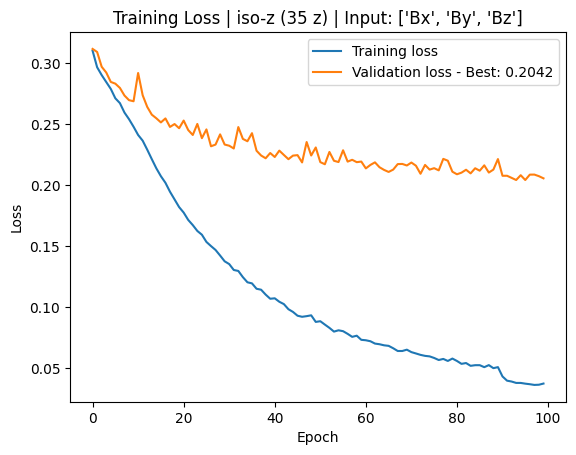

In [13]:
# Plot of losses
#################

import matplotlib.pyplot as plt
plt.plot(Train_loss, label = "Training loss")
plt.plot(Val_loss, label = f"Validation loss - Best: {best_val_loss:.4f}")
plt.title(f'Training Loss | iso-z ({N_Z} z) | Input: {use_inputs}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'loss_curve_z.no{N_Z}.png', dpi=150, bbox_inches='tight')
plt.show()

## Calling the model

In [14]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load('best_unet.pth', map_location=device))
model.eval()

# (1536,1536,175) - (1,175,1536,1536)
x_tensor = torch.from_numpy(X_test.transpose(2,0,1)[None]).float().to(device)
print(f"Test input tensor: {x_tensor.shape}")

with torch.no_grad():
    pred_norm = model(x_tensor).cpu().numpy()[0]   # (3,1536,1536)


m = norm_stats['tau']['mean'].reshape(-1,1,1)   # (3,1,1)
s = norm_stats['tau']['std'].reshape(-1,1,1)
pred_real = (pred_norm * (s + 1e-8) + m).transpose(1,2,0)  # (1536,1536,3)
truth_real = tau_test_p                                      # (1536,1536,3) 

print(f"pred:  {pred_real.shape} | truth: {truth_real.shape}")

Test input tensor: torch.Size([1, 105, 1536, 1536])
pred:  (1536, 1536, 3) | truth: (1536, 1536, 3)


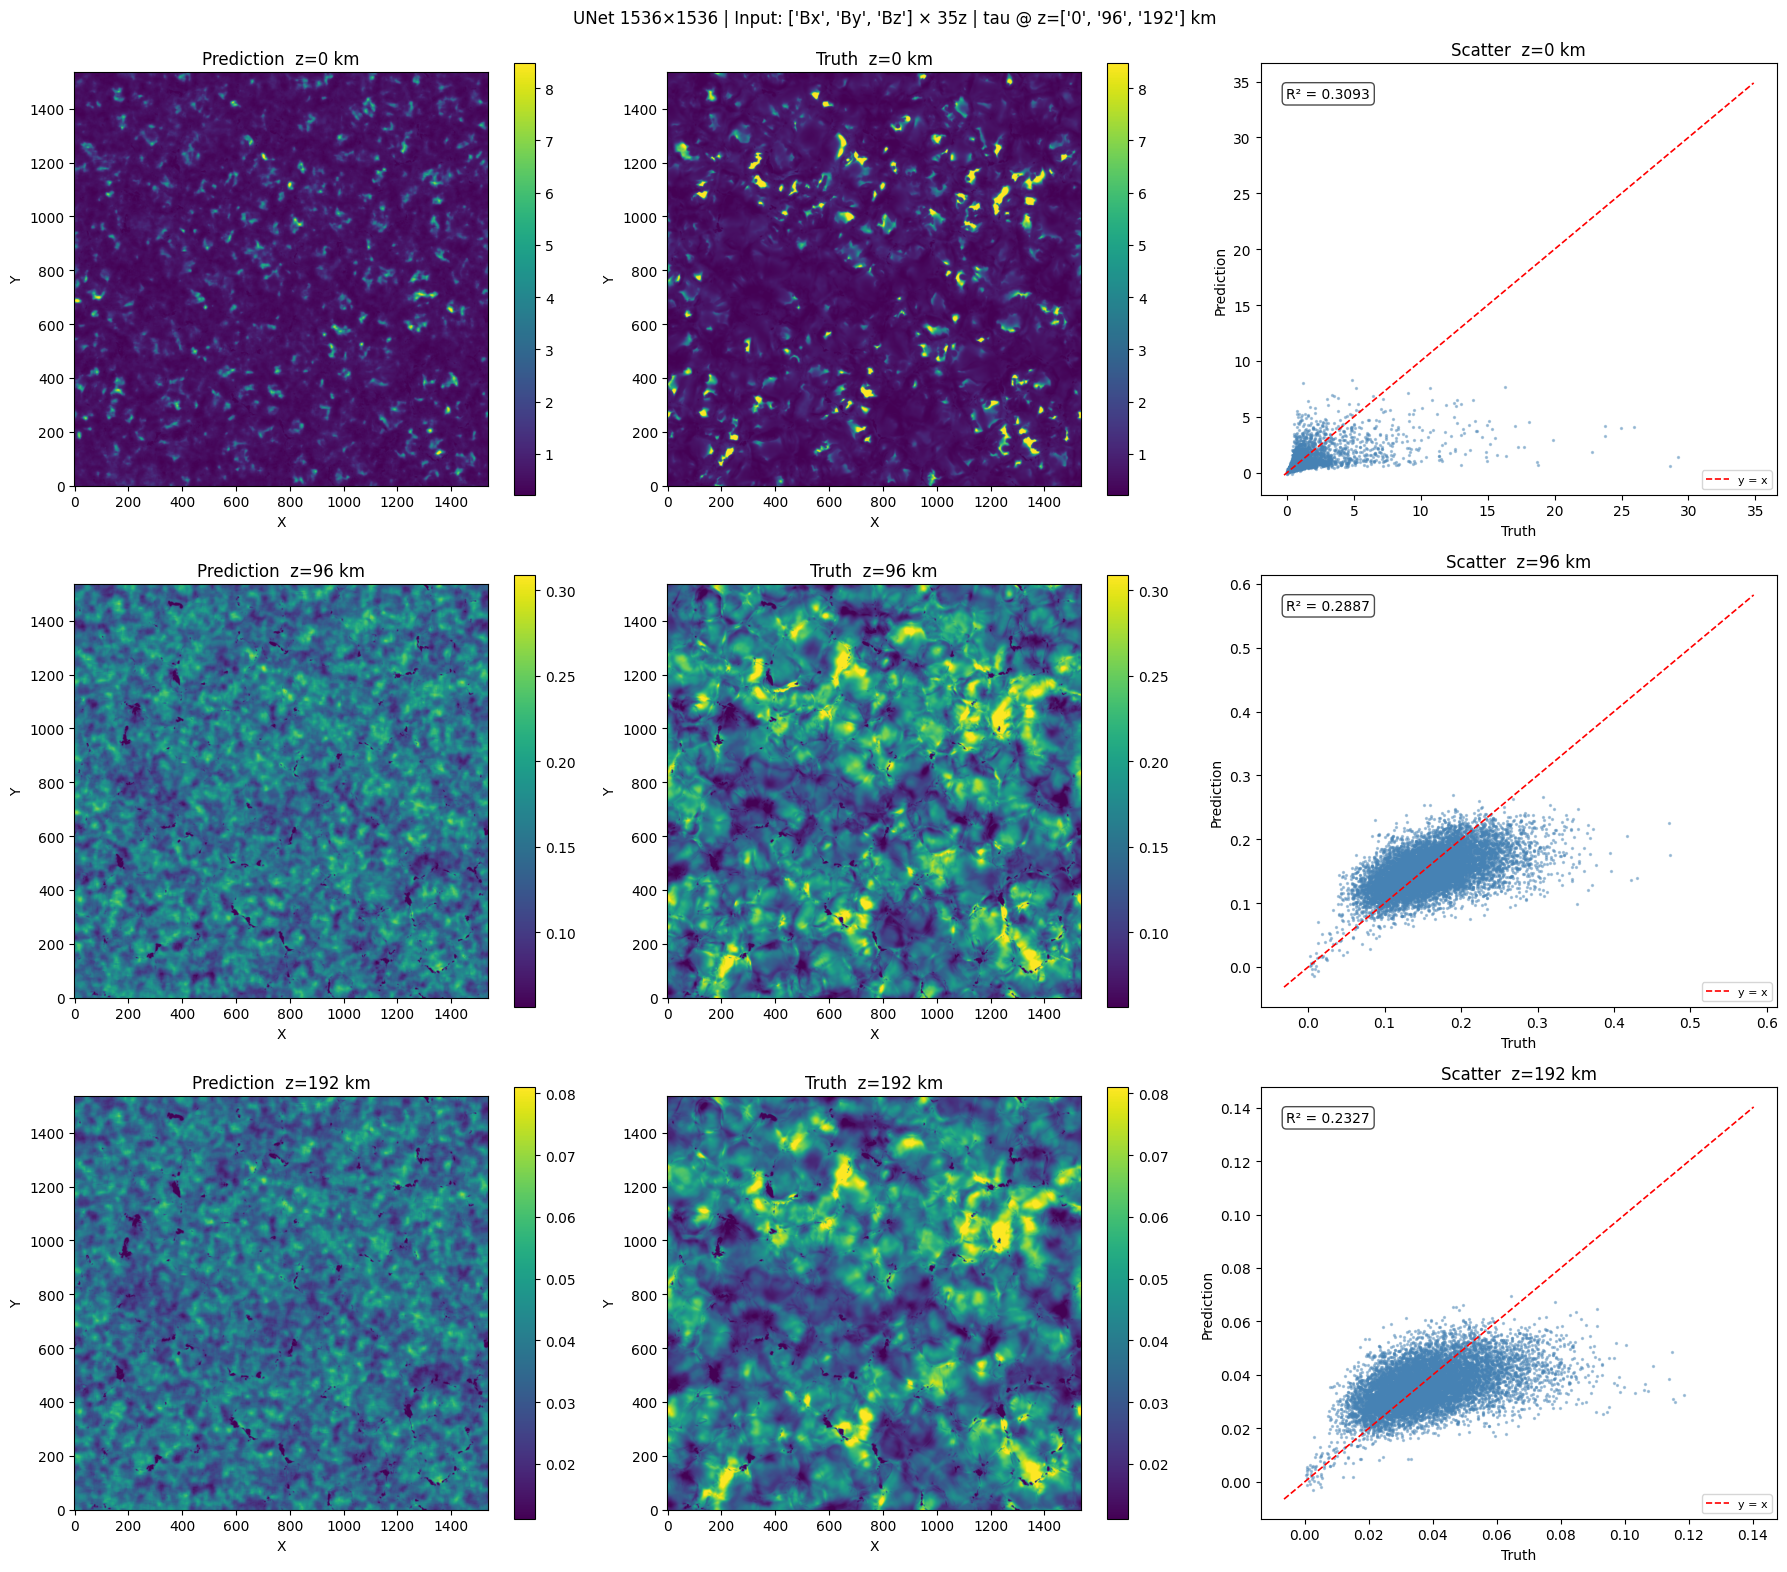

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

for row, z_idx in enumerate(range(3)):   
    ps   = pred_real[:,:,z_idx]
    ts   = truth_real[:,:,z_idx]
    zlbl = z_axis[Z_LEVELS[z_idx]]
    vmin, vmax = np.percentile(ts, 1), np.percentile(ts, 99)

    # Prediction
    im0 = axes[row,0].imshow(ps.T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(im0, ax=axes[row,0])
    axes[row,0].set_title(f'Prediction  z={zlbl:.0f} km')

    # Truth 
    im1 = axes[row,1].imshow(ts.T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(im1, ax=axes[row,1])
    axes[row,1].set_title(f'Truth  z={zlbl:.0f} km')

    # Scatter: prediction vs truth
    ps_flat = ps.ravel()
    ts_flat = ts.ravel()
    subsample = max(1, len(ps_flat) // 10_000)  
    axes[row,2].scatter(
        ts_flat[::subsample],
        ps_flat[::subsample],
        s=2, alpha=0.4, color='steelblue', rasterized=True
    )
    # Perfect-prediction diagonal
    diag_min = min(ts_flat.min(), ps_flat.min())
    diag_max = max(ts_flat.max(), ps_flat.max())
    axes[row,2].plot([diag_min, diag_max], [diag_min, diag_max],
                     'r--', linewidth=1.2, label='y = x')
    # Pearson R2
    r = np.corrcoef(ts_flat, ps_flat)[0, 1]
    axes[row,2].text(0.05, 0.92, f'R² = {r**2:.4f}',
                     transform=axes[row,2].transAxes,
                     fontsize=10, color='black',
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    axes[row,2].set_xlabel('Truth')
    axes[row,2].set_ylabel('Prediction')
    axes[row,2].set_title(f'Scatter  z={zlbl:.0f} km')
    axes[row,2].legend(fontsize=8)

    for ax in axes[row, :2]:
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

fig.suptitle(f'UNet 1536×1536 | Input: {use_inputs} × 35z | tau @ z={[f"{z_axis[i]:.0f}" for i in Z_LEVELS]} km')
plt.tight_layout(rect=[0,0,1,0.99])
plt.savefig('reconstruction_full.png', dpi=150, bbox_inches='tight')
plt.show()